# 정리

SEOYEON CHOI  
2025-03-06

# 1. **R, SAS, Python을 사용하여 통계 분석을 수행한 경험**

## 1.1. `R`은 주로 데이터 시각화와 모델링에 사용

-   `ggplot2`, `dplyr`, `tidyr`

In [1]:
import rpy2

In [4]:
%load_ext rpy2.ipython

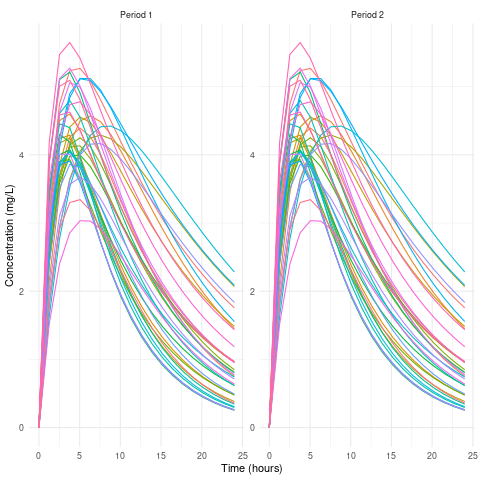

In [10]:
%%R
library(ggplot2)
library(dplyr)

two_compartment_model <- function(t, ka, ke, Vc, Vp, dose) {
  Cp <- dose / (Vc + Vp) * (ka / (ka - ke)) * (exp(-ke * t) - exp(-ka * t))
  return(Cp)
}

t <- seq(0, 24, length.out = 20)

n_subjects <- 36

ka_values <- runif(n_subjects, min = 0.2, max = 0.8)
ke_values <- runif(n_subjects, min = 0.05, max = 0.15)  
Vc_values <- runif(n_subjects, min = 8, max = 12) 
Vp_values <- runif(n_subjects, min = 3, max = 7)   
dose <- 100 

seq <- rep(c('1', '2'), each = 18)
set.seed(123)
seq <- sample(seq) 

Conc1 <- list()
Conc2 <- list()

for (i in 1:n_subjects) {
  ka <- ka_values[i]
  ke <- ke_values[i]
  Vc <- Vc_values[i]
  Vp <- Vp_values[i]
  period <- seq[i] 
  
  Cp <- two_compartment_model(t, ka, ke, Vc, Vp, dose)
  Conc1[[i]] <- Cp
}

for (i in 1:n_subjects) {
  ka <- ka_values[i]
  ke <- ke_values[i]
  Vc <- Vc_values[i]
  Vp <- Vp_values[i]
  period <- seq[i]  
  
  Cp <- two_compartment_model(t, ka, ke, Vc, Vp, dose)
  Conc2[[i]] <- Cp
}

df1 <- data.frame(
  Time = rep(t, n_subjects),
  Concentration = unlist(Conc1),
  Subject = rep(1:n_subjects, each = length(t)),
  Period = rep("Period 1", n_subjects * length(t))
)

df2 <- data.frame(
  Time = rep(t, n_subjects),
  Concentration = unlist(Conc2),
  Subject = rep(1:n_subjects, each = length(t)),
  Period = rep("Period 2", n_subjects * length(t))
)

df <- bind_rows(df1, df2)

ggplot(df, aes(x = Time, y = Concentration, group = Subject, color = factor(Subject))) +
  geom_line() +
    facet_wrap(~ Period, scales = "free_y") +
    xlab("Time (hours)") +
    ylab("Concentration (mg/L)") +
    theme_minimal() +
    theme(legend.position = "none")

-   Python Version
    [link](https://seoyeonc.github.io/md/posts/anything/2023-06-15-PK%20Analysis.html)

## 1.2. `SAS`는 주로 임상 시험 데이터 분석에 사용

-   STDM으로 ADAM set을 구성하는 CDISC standards 기반

## 1.3. `Python`은 주로 논문 분석에 사용

-   `pandas`, `numpy`, `scipy`, `statsmodels` 등을 활용하여 데이터
    전처리 및 통계 모델링을 진행합

# 2. **임상 시험 데이터에서 통계 분석을 어떻게 진행했는지 설명**

## 2.1. 임상 시험에서는 주로 환자 그룹 간의 차이를 분석하기 위해 t-검정, ANOVA, 회귀 분석 등을 사용

-   t-test
    -   순서군간 검정(나이, 키, 몸무게 평균이 다른지 등)
-   ANOVA
    -   2 by 2
        -   fisrt parameters(보통 auc, cmax)의 log 변환값을 종속변수로
            놓고 치료군, 시기군, 순서군은 고정효과, 개인별 차이는
            랜덤효과로 놓고 mixed effect model 결과 확인
        -   `sas`로 분석해서 `proc mixed`, `proc glm` 사용
        -   고정 효과는 일정한 효과를 미치는 변수들,
        -   랜덤 효과는 그룹 안에서도 달라질 수 있는 변수들
-   회귀분석
    -   항정상태 확인할때, 평균이 0과 같은지 등

## 2.2. Cox 비례 위험 모형을 통해 생존 분석을 진행

-   정리
    [link](https://seoyeonc.github.io/md/posts/anything/2023-04-17-Survival_Analysis.html)
-   Cox 비례 위험 모형은 생존 분석에서 사용된다. 특정 event가 발생하는
    시간을 분석할때 사용되며, hazard rate를 예측한다.
-   Cox 비례 위험 모형은 비례 위험 가정이 핵심이다. 독립 변수들이
    event에 시간이 지날수록 일정한 rate로 영향을 미친다고 가정한다.
    -   시간도 일정하게 지나가고 event 발생하는 위험도 일정하게
        변화한다고 본다.
-   시간 t에서의 위험함수를 구하기
    -   기초 위험 함수와 각 독립변수의 hazard ratio의 곱
-   cox 모형은 기초 위험 함수를 추정하지 않고 hazard ratio만 추정한다.
    -   각 변수들의 변화가 시간 t에 미치는 영향을 비교할 수 있지만, 위험
        함수는 모른다.
-   cox는 비모수적 모델이기 때문에 기초 함수를 몰라도 결과를 해석할 수
    있다.

`-` Kaplan-Meier 생존 분석을 어떻게 수행

-   Kaplan-Meier 방법은 환자의 생존 시간을 분석하는 데 사용
-   시간에 따른 생존 확률을 추정
-   치료 그룹 간 생존 곡선을 비교
-   로그순위 테스트를 통해 두 그룹 간의 생존 곡선이 유의미하게 차이가
    나는지 확인

## 2.3. 혼합 모델을 사용하여 반복 측정 데이터를 분석

-   순서군은 1개이고 한 대상자가 약을 매 visit마다 먹고 visit 1, visit
    2, visit 3에 혈압 검사를 진행할때 반복측정
    -   Visit은 고정효과로 놓고 대상자는 랜덤 효과로 놓고 y는 혈압
        결과로 놓고 분석
        -   Visit 2,3의 p value에 따라 0.05를 기준으로 놓고 이보다
            작으면 유의미하게 변화했다고 볼 수 있음

데이터를 정리할 때는 `SAS`를 사용하여 결측값 처리, 이상치 검토 등을
진행하며, 통계적으로 유의미한 결과를 도출하기 위해 여러 가지 방법을 비교

# 3. **가설 검정에서 p-value와 신뢰 구간의 차이점**

## 3.1. p value

-   가설 검정에서 귀무 가설의 기각 여부를 판단할 수 있는 척도.
    -   일반적 기각 기준은 0.05
    -   단일 검정에 대한 결과 제공

## 3.2. Confidence Interval

-   95% 신뢰 구간은 추정치가 95%의 확률로 이 구간에 포함된다는 의미
    -   신뢰 구간은 추정값의 범위를 제공

# 4. **임상 데이터에서 결측치를 처리하는 방법에 대해 설명**

1상 임상에서 농도의 결측치 대체해 본 경험은 없음.

다만 이상반응 결과에서 결측 날짜에 대한 결측치 대체 경험은 있으나 설명
복잡하여 패스..

# 5. **임상 시험의 유효성과 안전성 분석을 진행 방법**

## 5.1. 유효성

-   치료가 효과적인가?
    -   mixed model을 이용하여 primary parmeters 값 비교로 동등성 확인

## 5.2. 안전성

-   부작용은 없나?이상사례는 어느정도인가?
    -   이상사례가 치료군별로 어떻게 일어났는지 빈도 분석한 후 카이제곱
        검정하여 동등성 확인.

# 6. **임상 시험에서 샘플 크기**

목표는 제1종오류를 줄이는 것(효과 있는데 없다고 할 확률)

-   적절한 샘플 사이즈는 연구비의 낭비를 줄여주고 연구의 신뢰도를
    높여준다.
-   샘플 사이즈를 계산할 때 고려해야 할 주요 요소는 유의수준(보통 0.05),
    검정력(80% 이상), 효과크기, 그리고 표준편차.

# 7. **정규성 검정을 위한 방법**

-   Shapiro-Wilk 테스트, Kolmogorov-Smirnov 테스트, Anderson-Darling
    테스트와 같은 방법을 사용
-   히스토그램, Q-Q 플롯 등을 시각적으로 활용하여 데이터의 분포가
    정규분포에 얼마나 근접한지 확인
-   정규성을 만족하지 않으면 비모수 검정 방법이나 로그 변환 등을 고려

시계열 teaching assistance할때, 기업 실무자들을 대상으로 했었는데,
그들이 실제 연구에서 정규성 검정의 중요성에 대해 질문했다.

사실 n수가 30이 넘어가면 큰 수의 법칙에 따라 정규성을 만족한다고
가정하기 때문에 실제 분석에서는 영향이 없게 볼 수 있다.

하지만 이상치는 체크해야함

# 8. **선형 회귀 모델에서 다중공선성을 해결하는 방법**

-   다중공선성 문제는 독립 변수들 간에 높은 상관관계를 가질때 발생
-   회귀 계수 추정 결과의 신뢰도에 영향을 미침
-   단계적 회귀, lasso 회귀, pca 등으로 공선성을 줄일 수 있고,
-   VIF Variance Inflation Factor를 계산해서 다중 공선성이 높은 factor를
    select해서 remove하거나 결합하는 방법을 사용할 수 있음

# 9. **주성분 분석(PCA)**

정리
[link](https://seoyeonc.github.io/md/posts/ml_basic/2023-03-28-Principal%20Component%20Analysis.html#%EC%95%95%EC%B6%95%EC%9D%84-%EC%9C%84%ED%95%9C-pca)

-   고차원 데이터를 차원 축소하여 주요 변수들만을 추출할 때 유용
-   변수 간의 상관관계가 높은 경우, PCA를 통해 주요 구성 요소를 추출하고
    이를 통해 데이터를 분석